# Linear Regression

Full Bayesian workflow: prior predictive → posterior sampling → ArviZ diagnostics.

**Model:**
$$\beta \sim \text{Normal}(0, 5)$$
$$\sigma \sim \text{HalfNormal}(2)$$
$$y_i \sim \text{Normal}(\beta \cdot x_i,\ \sigma)$$

In [1]:
import numpy as np
import rustmc as rmc
import arviz as az
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

/home/taylo/projects/rustmc/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Generate Data

In [2]:
np.random.seed(42)
N = 500
x = np.random.randn(N)
beta_true  = 2.5
sigma_true = 1.5
y = beta_true * x + np.random.normal(0, sigma_true, N)

print(f"N={N}, beta_true={beta_true}, sigma_true={sigma_true}")

N=500, beta_true=2.5, sigma_true=1.5


## Build and Sample

In [3]:
builder = rmc.ModelBuilder(data={"x": x, "y": y})
beta  = builder.normal_prior("beta",  mu=0.0, sigma=5.0)
sigma = builder.half_normal_prior("sigma", sigma=2.0)
builder.normal_likelihood("obs", mu_expr=beta * "x", sigma=sigma, observed_key="y")
model = builder.build()

fit = rmc.sample(model_spec=model, chains=4, draws=2000, warmup=1000, seed=42)
print(fit.summary())

4 chains × 2000 draws per chain

Parameter        mean      std     hdi_3%    hdi_97%   ess_bulk   ess_tail    r_hat  mcse_mean
────────────────────────────────────────────────────────────────────────────────────────────────
beta           2.3844   0.0647     2.2625     2.5037       1883       3169   1.0084   0.001491
sigma          1.4654   0.0464     1.3796     1.5534       7998       7998   1.0003   0.000519
────────────────────────────────────────────────────────────────────────────────────────────────
Mean accept rate: 0.89  │  Divergences: 45
⚠  45 divergent transitions — results may be unreliable.


Sampling done: 12000/12000 | 45 div | elapsed 1s


## ArviZ Diagnostics

In [4]:
idata = fit.to_arviz()
az.summary(idata, round_to=4)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,2.3844,0.0647,2.2641,2.5044,0.0019,0.0011,1163.6527,1704.7791,1.0084
sigma,1.4654,0.0464,1.3801,1.5538,0.0006,0.0006,6353.5804,4731.3649,1.0005


## Trace Plot

Checks stationarity and chain mixing. All chains should overlap and show no trends.

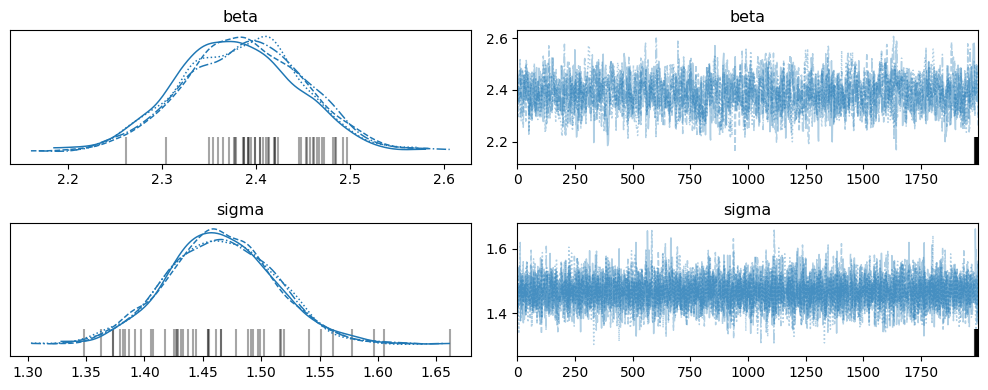

In [5]:
az.plot_trace(idata, figsize=(10, 4))
plt.tight_layout()
plt.show()

## Posterior Distributions

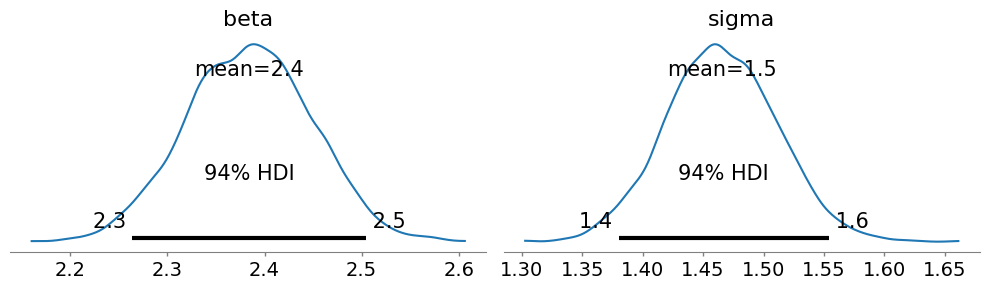

beta:  true=2.5  estimated=2.3844 ± 0.0647
sigma: true=1.5  estimated=1.4654 ± 0.0464


In [6]:
az.plot_posterior(idata, figsize=(10, 3))
plt.tight_layout()
plt.show()

means = fit.mean()
stds  = fit.std()
print(f"beta:  true={beta_true}  estimated={means['beta']:.4f} ± {stds['beta']:.4f}")
print(f"sigma: true={sigma_true}  estimated={means['sigma']:.4f} ± {stds['sigma']:.4f}")

## Posterior Predictive Check

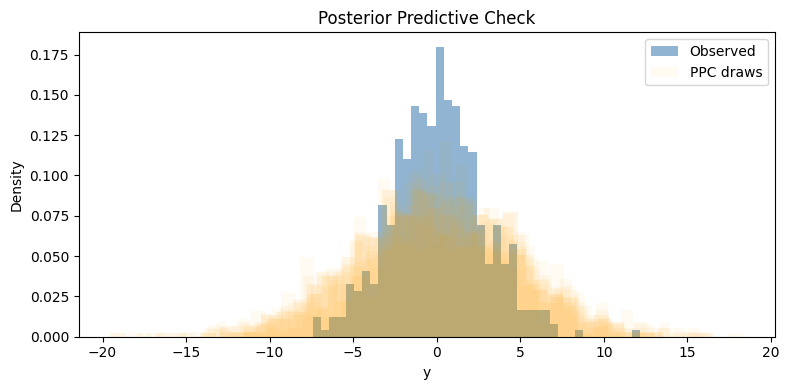

PPC p-value (std): 1.000  (0.5 = perfect calibration)


In [7]:
ppc   = fit.posterior_predictive(n_samples=500, seed=42)
y_rep = ppc["obs"]  # (500, N)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y, bins=40, density=True, alpha=0.6, color='steelblue', label='Observed')
for i in range(0, 500, 50):
    ax.hist(y_rep[i], bins=40, density=True, alpha=0.05, color='orange')
ax.hist(y_rep[0], bins=40, density=True, alpha=0.05, color='orange', label='PPC draws')
ax.set_xlabel('y')
ax.set_ylabel('Density')
ax.set_title('Posterior Predictive Check')
ax.legend()
plt.tight_layout()
plt.show()

ppc_p = (y_rep.std(axis=1) > y.std()).mean()
print(f"PPC p-value (std): {ppc_p:.3f}  (0.5 = perfect calibration)")